# Assignment 06 — Part 0: concepts, functions and operators of an RNN

**Author:** Lưu Anh Dũng (B23DCDK036) | **Course:** Intelligent System Development | **Lecturer:** Assoc. Prof. Dinh Que Tran, Ph.D.

The two dataset notebooks ([ec_olist.ipynb](ec_olist.ipynb), [st_nyse.ipynb](st_nyse.ipynb)) use one idea: a network that reads a sequence one step at a time and carries a **memory** from step to step. This notebook builds that idea from its parts. Every formula comes with a small numeric example, and every example is **checked in code** (`assert`) against NumPy, PyTorch or Keras.

Running examples, taken from the two datasets:
* delivery times (days) of successive Olist orders to one state: `8, 12, 9, 15, 7, 21, 10`;
* a stock's daily trading range (%): `1.2, 1.1, 2.9, 2.4, 1.8`.

In [1]:
import os; os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "3")
import numpy as np, matplotlib.pyplot as plt, seaborn as sns, torch, torch.nn as nn
from numpy.lib.stride_tricks import sliding_window_view
sns.set_theme(style="whitegrid"); np.set_printoptions(precision=4, suppress=True)
rng = np.random.default_rng(7); torch.manual_seed(7)

## 1. Sequences as data

A dense network maps one vector to one output and does not know which input came first. In a sequence the **order is the information**: delivery times `8, 12, 15` (logistics getting worse) and `15, 12, 8` (recovering) have the same mean but should give different forecasts.

**Sliding window.** A series $s_1..s_n$ becomes supervised pairs (input = $T$ consecutive values, target = the next one). With $T=3$ the 7 delivery times give $7-3=4$ pairs:

| input $(s_{k},s_{k+1},s_{k+2})$ | target $s_{k+3}$ |
|---|---|
| 8, 12, 9 | 15 |
| 12, 9, 15 | 7 |
| 9, 15, 7 | 21 |
| 15, 7, 21 | 10 |

Stacked, the inputs form a tensor of shape $(N,T,F)$ = (windows, time steps, features per step) = $(4,3,1)$ here; in the EC notebook $(96\text{k},10,10)$, in ST $(433\text{k},30,7)$.

**Task shapes.** *many-to-one* (read $T$ steps, output one number — both notebooks), *many-to-many* (an output at every step, e.g. tagging each day), *one-to-many* (generate a sequence). Only which $h_t$ are fed to the output layer changes.

**Order of time also constrains evaluation:** train on the past, validate and test on the future; a random split would let the model see days *after* the ones it is tested on.

In [2]:
gaps = np.array([8, 12, 9, 15, 7, 21, 10], float); T_ = 3
X = sliding_window_view(gaps[:-1], T_)[:, :, None]           # (N, T, F): the last value is never an input
y = gaps[T_:]
print("X shape (N, T, F) =", X.shape)
for a, b in zip(X[:, :, 0], y): print(a, "->", b)
assert X.shape == (4, 3, 1) and np.array_equal(y, [15, 7, 21, 10])
print("same mean, different order:", np.mean([8, 12, 15]), np.mean([15, 12, 8]))

X shape (N, T, F) = (4, 3, 1)
[ 8. 12.  9.] -> 15.0
[12.  9. 15.] -> 7.0
[ 9. 15.  7.] -> 21.0
[15.  7. 21.] -> 10.0
same mean, different order: 11.666666666666666 11.666666666666666


## 2. The operators

| Operator | Definition | Example | Where in the RNN |
|---|---|---|---|
| matrix product $xW$ | $(xW)_j=\sum_i x_iW_{ij}$ | $[2,1]\begin{bmatrix}1&-1\\0.5&2\end{bmatrix}=[2.5,\,0]$ | mixes inputs and memory into $H$ new values |
| addition of a bias $b$ | shift per unit | $[2.5,0]+[-0.5,0.1]=[2,0.1]$ | lets a unit be "on" without input |
| $\tanh(z)=\frac{e^z-e^{-z}}{e^z+e^{-z}}$ | squashes to $(-1,1)$ | $\tanh 2=0.964$, $\tanh 0.1=0.0997$ | the RNN state; centred at 0, so memory can be + or − |
| $\sigma(z)=\frac1{1+e^{-z}}$ | squashes to $(0,1)$ | $\sigma(0)=0.5$, $\sigma(3)=0.953$ | **gates**: "how much to let through" |
| element-wise (Hadamard) $a\odot b$ | $(a\odot b)_i=a_ib_i$ | $[0.95,0.1]\odot[2,2]=[1.9,0.2]$ | applying a gate to a value |
| softmax | $e^{z_i}/\sum_j e^{z_j}$ | $[2,1,0]\to[0.665,0.245,0.090]$ | output for classification (e.g. "up / flat / down") |

**Derivatives used in back-propagation** (both expressible through the output itself, so they are cheap):
$\tanh'(z)=1-\tanh^2(z)$: at $z=2$, $1-0.964^2=0.071$ — a saturated unit passes only 7 % of a gradient.
$\sigma'(z)=\sigma(z)(1-\sigma(z))$: at most $0.25$ (at $z=0$).

**Concatenation trick.** $x_tW_{xh}+h_{t-1}W_{hh}=[x_t,h_{t-1}]\begin{bmatrix}W_{xh}\\W_{hh}\end{bmatrix}$ — one big product instead of two. Frameworks use it for speed; the math is identical.

softmax([2,1,0]) = [0.6652 0.2447 0.09  ]
tanh'(2.0): formula 0.0707, finite difference 0.0707
sigmoid'(0.0): formula 0.2500, finite difference 0.2500
[x, h] @ [[Wxh],[Whh]] == x Wxh + h Whh


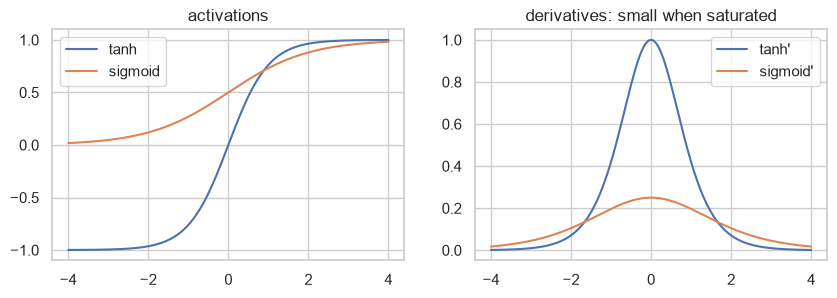

In [3]:
x = np.array([2., 1.]); W = np.array([[1, -1], [0.5, 2]]); b = np.array([-0.5, 0.1])
assert np.allclose(x @ W, [2.5, 0]) and np.allclose(x @ W + b, [2, 0.1])
sig = lambda z: 1 / (1 + np.exp(-z))
assert np.isclose(np.tanh(2), 0.9640, atol=1e-4) and np.isclose(sig(3), 0.9526, atol=1e-4)
assert np.allclose(np.array([0.95, 0.1]) * 2, [1.9, 0.2])
sm = np.exp([2, 1, 0]) / np.exp([2, 1, 0]).sum(); print("softmax([2,1,0]) =", sm); assert np.allclose(sm, torch.softmax(torch.tensor([2., 1, 0]), 0).numpy())

# derivatives: formula vs central finite difference
for name, f, df, z in (("tanh", np.tanh, lambda z: 1 - np.tanh(z) ** 2, 2.0), ("sigmoid", sig, lambda z: sig(z) * (1 - sig(z)), 0.0)):
    num = (f(z + 1e-6) - f(z - 1e-6)) / 2e-6; print(f"{name}'({z}): formula {df(z):.4f}, finite difference {num:.4f}"); assert np.isclose(df(z), num)

# concatenation trick
F, Hh = 3, 4; xt, hp = rng.normal(size=F), rng.normal(size=Hh); Wx, Wh = rng.normal(size=(F, Hh)), rng.normal(size=(Hh, Hh))
assert np.allclose(xt @ Wx + hp @ Wh, np.r_[xt, hp] @ np.vstack([Wx, Wh])); print("[x, h] @ [[Wxh],[Whh]] == x Wxh + h Whh")

z = np.linspace(-4, 4, 200)
fig, ax = plt.subplots(1, 2, figsize=(10, 3))
ax[0].plot(z, np.tanh(z), label="tanh"); ax[0].plot(z, sig(z), label="sigmoid"); ax[0].legend(); ax[0].set(title="activations")
ax[1].plot(z, 1 - np.tanh(z) ** 2, label="tanh'"); ax[1].plot(z, sig(z) * (1 - sig(z)), label="sigmoid'"); ax[1].legend(); ax[1].set(title="derivatives: small when saturated")
plt.show()

## 3. One RNN step, unrolling, weight sharing

$$h_t=\tanh\big(x_tW_{xh}+h_{t-1}W_{hh}+b\big),\qquad h_0=0,\qquad \hat y=h_TW_{hy}+b_y$$

Sizes: $x_t\in\mathbb R^F$, $h_t\in\mathbb R^H$, $W_{xh}\in\mathbb R^{F\times H}$, $W_{hh}\in\mathbb R^{H\times H}$, $b\in\mathbb R^H$, $W_{hy}\in\mathbb R^{H\times1}$.

**Hand example** ($F=1$, $H=2$) on the stock ranges `1.2, 1.1, 2.9` (centred: minus 1.5 → `-0.3, -0.4, 1.4`), with $W_{xh}=[0.8,\,-0.5]$, $W_{hh}=\begin{bmatrix}0.5&0\\0.2&0.3\end{bmatrix}$, $b=0$:

| $t$ | $x_t$ | $z_t=x_tW_{xh}+h_{t-1}W_{hh}$ | $h_t=\tanh z_t$ |
|---|---|---|---|
| 1 | −0.3 | $[-0.24,\ 0.15]$ | $[-0.2355,\ 0.1489]$ |
| 2 | −0.4 | $[-0.32-0.1178+0.0298,\ 0.20+0.0447]=[-0.4080,\ 0.2447]$ | $[-0.3867,\ 0.2399]$ |
| 3 | 1.4 | $[1.12-0.1934+0.0480,\ -0.70+0.0720]=[0.9746,\ -0.6280]$ | $[0.7507,\ -0.5567]$ |

Unit 1 tracks "risk is high now", unit 2 the opposite; the two calm days still leave a trace in $z_3$ through $h_2W_{hh}$.

**Unrolling.** The loop over $t$ written out is a feed-forward chain of $T$ copies of the same cell. **Weight sharing:** all copies use the same $W_{xh},W_{hh},b$, so the parameter count $FH+H^2+H$ does not depend on $T$ — the 10-order EC windows and the 30-day ST windows use cells of the same size.

In [4]:
Wxh = np.array([[0.8, -0.5]]); Whh = np.array([[0.5, 0], [0.2, 0.3]]); bh = np.zeros(2)
xs = np.array([1.2, 1.1, 2.9]) - 1.5; h = np.zeros(2); H_rec = []
for t, xt in enumerate(xs, 1):
    z = xt * Wxh[0] + h @ Whh + bh; h = np.tanh(z); H_rec.append(h); print(f"t={t}: z={z}, h={h}")
assert np.allclose(H_rec[-1], [0.7507, -0.5567], atol=1e-4)

# the same with PyTorch's nn.RNN (weights are stored transposed: weight_ih = Wxh^T)
rnn = nn.RNN(1, 2, batch_first=True, bias=False)
with torch.no_grad(): rnn.weight_ih_l0.copy_(torch.tensor(Wxh.T)); rnn.weight_hh_l0.copy_(torch.tensor(Whh.T))
out, hT = rnn(torch.tensor(xs, dtype=torch.float32).view(1, 3, 1))
print("nn.RNN h_3 =", hT.detach().numpy().ravel()); assert np.allclose(hT.detach().numpy().ravel(), H_rec[-1], atol=1e-6)

# weight sharing: parameter count is independent of T
m = nn.RNN(7, 32, batch_first=True); n_par = sum(p.numel() for p in m.parameters())
for T_len in (3, 10, 30):
    out, hT = m(torch.randn(2, T_len, 7))
    print(f"T={T_len:2d}: input (2, {T_len}, 7) -> all states {tuple(out.shape)}, last state {tuple(hT[0].shape)}; parameters {n_par}")

t=1: z=[-0.24  0.15], h=[-0.2355  0.1489]
t=2: z=[-0.408   0.2447], h=[-0.3867  0.2399]
t=3: z=[ 0.9746 -0.628 ], h=[ 0.7507 -0.5567]
nn.RNN h_3 = [ 0.7507 -0.5567]
T= 3: input (2, 3, 7) -> all states (2, 3, 32), last state (2, 32); parameters 1312
T=10: input (2, 10, 7) -> all states (2, 10, 32), last state (2, 32); parameters 1312
T=30: input (2, 30, 7) -> all states (2, 30, 32), last state (2, 32); parameters 1312


**Memory as an impulse response.** Feed one small spike ($x_1=0.1$, then zeros) into a 1-unit RNN with $W_{xh}=1$. For small values $\tanh z\approx z$, so $h_t\approx 0.1\,w^{t-1}$ for a recurrent weight $w$. With $w=0.9$ the spike keeps $0.9^{9}=39\,\%$ after 10 steps; with $w=0.5$, $0.2\,\%$. The recurrent weight *is* the memory length.

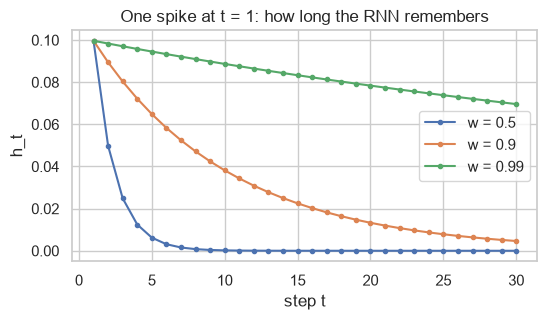

In [5]:
fig, ax = plt.subplots(figsize=(6, 3))
for w in (0.5, 0.9, 0.99):
    h = 0.0; trace = []
    for t in range(30): h = np.tanh((0.1 if t == 0 else 0.0) + w * h); trace.append(h)
    ax.plot(range(1, 31), trace, marker=".", label=f"w = {w}")
    if w == 0.9: assert abs(trace[9] / trace[0] - 0.9 ** 9) < 0.01            # geometric decay w^(t-1)
ax.set(xlabel="step t", ylabel="h_t", title="One spike at t = 1: how long the RNN remembers"); ax.legend()
fig.savefig("../report/images/C_memory.png", dpi=150, bbox_inches="tight"); plt.show()

## 4. Back-propagation through time (BPTT)

Training minimises $L=(\hat y-y)^2$ by gradient descent. Because $h_t$ depends on $h_{t-1}$, a weight used at every step receives a contribution **from every step**.

**Scalar example** (one unit, no bias): $h_t=\tanh(w\,x_t+u\,h_{t-1})$, $\hat y=h_2$, inputs $x=(1,\,0.5)$, $w=0.6$, $u=0.9$, target $y=0$.

Forward: $h_1=\tanh(0.6)=0.5370$; $h_2=\tanh(0.3+0.9\cdot0.5370)=\tanh(0.7833)=0.6546$; $L=0.6546^2=0.4285$.

Backward:
* $\partial L/\partial h_2=2(h_2-y)=1.3092$
* $\partial L/\partial z_2=1.3092\,(1-0.6546^2)=0.7482$
* step-2 share: $\partial z_2/\partial u=h_1$ → $0.7482\cdot0.5370=0.4018$
* to step 1: $\partial L/\partial h_1=0.7482\cdot u=0.6734$, $\partial L/\partial z_1=0.6734\,(1-0.5370^2)=0.4792$
* step-1 share: $\partial z_1/\partial u=h_0=0$ → $0$
* $\partial L/\partial u=0.4018+0=0.4018$; $\partial L/\partial w=0.7482\cdot x_2+0.4792\cdot x_1=0.3741+0.4792=0.8533$.

The general rule, vector form: $\delta_{t-1}=\big(\delta_t\odot(1-h_t^2)\big)W_{hh}^\top$ and $\partial L/\partial W_{hh}=\sum_t h_{t-1}^\top\big(\delta_t\odot(1-h_t^2)\big)$. PyTorch's autograd builds the same chain automatically — checked below.

In [6]:
x1, x2, w, u, y_ = 1.0, 0.5, 0.6, 0.9, 0.0
h1 = np.tanh(w * x1); h2 = np.tanh(w * x2 + u * h1); L = (h2 - y_) ** 2
dz2 = 2 * (h2 - y_) * (1 - h2 ** 2); dz1 = dz2 * u * (1 - h1 ** 2)
du = dz2 * h1 + dz1 * 0.0; dw = dz2 * x2 + dz1 * x1
print(f"h1={h1:.4f} h2={h2:.4f} L={L:.4f} | dL/du={du:.4f} dL/dw={dw:.4f}")

wt, ut = torch.tensor(w, requires_grad=True), torch.tensor(u, requires_grad=True)
h = torch.tanh(wt * x1); h = torch.tanh(wt * x2 + ut * h); ((h - y_) ** 2).backward()
print(f"autograd:            dL/du={ut.grad.item():.4f} dL/dw={wt.grad.item():.4f}")
assert np.isclose(du, ut.grad.item()) and np.isclose(dw, wt.grad.item()) and np.isclose(du, 0.4018, atol=1e-4) and np.isclose(dw, 0.8533, atol=1e-4)

h1=0.5370 h2=0.6546 L=0.4285 | dL/du=0.4018 dL/dw=0.8533
autograd:            dL/du=0.4018 dL/dw=0.8533


## 5. Vanishing and exploding gradients, gradient clipping

The signal from the loss to step $t$ is multiplied, for every step it travels back, by $\mathrm{diag}(1-h^2)\,W_{hh}^\top$. In the scalar case each step multiplies by $u(1-h^2)$:

| per-step factor | after 10 steps | after 30 steps |
|---|---|---|
| 0.5 | $0.5^{10}=0.001$ | $9\cdot10^{-10}$ (vanished) |
| 0.9 | 0.35 | 0.04 |
| 1.0 | 1 | 1 |
| 1.3 | 13.8 | 2,620 (exploded) |

*Vanishing*: early steps get almost no learning signal, so the RNN cannot learn dependencies longer than a few steps — matters for the 30-day ST windows more than for the 10-order EC windows. *Exploding*: one update can throw the weights far away (loss becomes `nan`).

**Gradient clipping by global norm** treats exploding gradients: if $\lVert g\rVert>c$, rescale $g\leftarrow g\cdot c/\lVert g\rVert$. Example: $g=(3,4)$, $\lVert g\rVert=5$, $c=1$ → $(0.6,0.8)$: the **direction is kept**, only the step length is capped. (Clipping each entry to $[-1,1]$ instead would give $(1,1)$ and change the direction.) All runs in this assignment use $c=1$. Vanishing gradients are *not* fixed by clipping; that is the job of gates (§6).

factor 0.5: 10 steps 0.000977, 30 steps 9.31e-10
factor 0.9: 10 steps 0.349, 30 steps 0.0424
factor 1.0: 10 steps 1, 30 steps 1
factor 1.3: 10 steps 13.8, 30 steps 2.62e+03


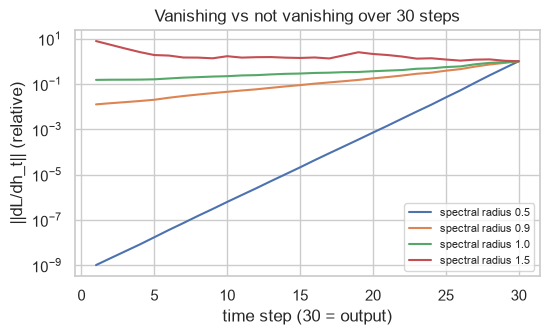

before [3.0, 4.0] norm 5.0 -> after [0.5999999046325684, 0.7999998331069946]


In [7]:
factors = (0.5, 0.9, 1.0, 1.3)
for f in factors: print(f"factor {f}: 10 steps {f**10:.3g}, 30 steps {f**30:.3g}")
assert np.isclose(1.3 ** 30, 2620, rtol=1e-3)

# measured on a real RNN: gradient norm reaching each of 30 steps, recurrent matrix scaled to spectral radius rho
def grad_to_steps(rho, T=30, H=16, seed=0):
    g = torch.Generator().manual_seed(seed)
    q, _ = torch.linalg.qr(torch.randn(H, H, generator=g)); Whh = rho * q
    Wx = 0.5 * torch.randn(1, H, generator=g); xs = torch.randn(T, 1, generator=g) * 0.3
    hs = [torch.zeros(1, H, requires_grad=True)]
    for t in range(T):
        hs[-1].retain_grad(); hs.append(torch.tanh(xs[t:t + 1] @ Wx + hs[-1] @ Whh))
    hs[-1].retain_grad(); hs[-1].sum().backward()
    return np.array([hs[t].grad.norm().item() for t in range(1, T + 1)])
fig, ax = plt.subplots(figsize=(6, 3.2))
for rho in (0.5, 0.9, 1.0, 1.5):
    n = grad_to_steps(rho); ax.semilogy(range(1, 31), n / n[-1], label=f"spectral radius {rho}")
ax.set(xlabel="time step (30 = output)", ylabel="||dL/dh_t|| (relative)", title="Vanishing vs not vanishing over 30 steps"); ax.legend(fontsize=8)
fig.savefig("../report/images/C_vanishing.png", dpi=150, bbox_inches="tight"); plt.show()

g = torch.tensor([3., 4.], requires_grad=False); p = torch.nn.Parameter(torch.zeros(2)); p.grad = g.clone()
total = torch.nn.utils.clip_grad_norm_([p], 1.0)
print("before", g.tolist(), "norm", total.item(), "-> after", p.grad.tolist()); assert np.allclose(p.grad.numpy(), [0.6, 0.8])

Note the $\rho=1.5$ curve: with tanh the state saturates ($1-h^2\to0$), which brakes the explosion — in tanh RNNs exploding gradients usually appear as rare spikes, which is exactly what clipping handles.

## 6. LSTM and GRU: gates

A **gate** is a vector $g=\sigma(\dots)\in(0,1)^H$ multiplied element-wise onto a value: $g\odot v$. $g_i=0.95$ keeps 95 % of $v_i$, $g_i=0.05$ almost erases it — and the network *learns* when to do which.

**GRU** (Cho et al., 2014), one state $h_t$:

$$\begin{aligned}
r_t&=\sigma(x_tW_r+h_{t-1}U_r+b_r) &&\text{reset: how much of the past to use in the candidate}\\
u_t&=\sigma(x_tW_u+h_{t-1}U_u+b_u) &&\text{update: how much to renew}\\
\tilde h_t&=\tanh\big(x_tW_h+r_t\odot(h_{t-1}U_h)+b_h\big) &&\text{candidate}\\
h_t&=(1-u_t)\odot\tilde h_t+u_t\odot h_{t-1}&&\text{(PyTorch convention)}
\end{aligned}$$

Example with one unit: $h_{t-1}=0.8$, $u_t=0.9$, $\tilde h_t=-0.5$ → $h_t=0.1\cdot(-0.5)+0.9\cdot0.8=0.67$: the old memory mostly survives a contradicting input. The gradient through that path is $\partial h_t/\partial h_{t-1}\approx u_t=0.9$ instead of $w(1-h^2)$ — an *additive* path that does not saturate.

**LSTM** (Hochreiter & Schmidhuber, 1997) has two states: cell $c_t$ (long memory) and output $h_t$:

$$c_t=f_t\odot c_{t-1}+i_t\odot\tilde c_t,\qquad h_t=o_t\odot\tanh(c_t),$$

with forget $f_t$, input $i_t$, output $o_t$ gates (sigmoids) and candidate $\tilde c_t=\tanh(\cdot)$. If $f=1,i=0$ the cell is copied unchanged for any number of steps ("constant error carousel"): $\partial c_t/\partial c_{t-1}=f_t=1$, no vanishing.

**Parameter counts** for input $F$, hidden $H$: RNN $H(F+H+1)$; GRU $3H(F+H+2)$ (two biases per block, Keras `reset_after=True` and PyTorch); LSTM $4H(F+H+1)$ in Keras, $4H(F+H+2)$ in PyTorch (two bias vectors).

In [8]:
F2, H2 = 3, 4
cell = nn.GRUCell(F2, H2); x = torch.randn(1, F2); hprev = torch.tanh(torch.randn(1, H2))
Wi, Wh, bi, bh_ = cell.weight_ih, cell.weight_hh, cell.bias_ih, cell.bias_hh          # rows stacked [reset, update, new]
gi = x @ Wi.T + bi; gh = hprev @ Wh.T + bh_
ir, iu, inn = gi.chunk(3, 1); hr, hu, hn = gh.chunk(3, 1)
r = torch.sigmoid(ir + hr); u = torch.sigmoid(iu + hu)
n = torch.tanh(inn + r * hn)                                     # reset gate applied to (h U_h + b_hn)
h_hand = (1 - u) * n + u * hprev
print("GRU by hand :", h_hand.detach().numpy().ravel()); print("nn.GRUCell  :", cell(x, hprev).detach().numpy().ravel())
assert torch.allclose(h_hand, cell(x, hprev), atol=1e-6)
assert np.isclose(0.1 * -0.5 + 0.9 * 0.8, 0.67)

# LSTM constant error carousel: f = 1, i = 0 keeps the cell for 100 steps; f = 0.9 forgets geometrically
c = 2.0
print("f=1, i=0 for 100 steps ->", c * 1.0 ** 100, "|  f=0.9 ->", round(c * 0.9 ** 100, 6))

for F_, H_ in ((10, 32), (7, 32)):
    rows = {k: sum(p.numel() for p in m.parameters()) for k, m in (("RNN", nn.RNN(F_, H_)), ("GRU", nn.GRU(F_, H_)), ("LSTM", nn.LSTM(F_, H_)))}
    assert rows["GRU"] == 3 * H_ * (F_ + H_ + 2) and rows["LSTM"] == 4 * H_ * (F_ + H_ + 2) and rows["RNN"] == H_ * (F_ + H_ + 2)
    print(f"F={F_}, H={H_}: PyTorch parameters (cell only)", rows)

GRU by hand : [0.3996 0.6767 0.1412 0.2985]
nn.GRUCell  : [0.3996 0.6767 0.1412 0.2985]
f=1, i=0 for 100 steps -> 2.0 |  f=0.9 -> 5.3e-05
F=10, H=32: PyTorch parameters (cell only) {'RNN': 1408, 'GRU': 4224, 'LSTM': 5632}
F=7, H=32: PyTorch parameters (cell only) {'RNN': 1312, 'GRU': 3936, 'LSTM': 5248}


## 7. One layer, three names

| Item | Scratch (NumPy) | Keras `SimpleRNN(H)` | PyTorch `nn.RNN(F, H, batch_first=True)` |
|---|---|---|---|
| Input layout | `(N, T, F)` | `(N, T, F)` | `(N, T, F)` only with `batch_first=True` (default `(T, N, F)`) |
| $W_{xh}$ | `Wxh` $(F,H)$ | `kernel` $(F,H)$ | `weight_ih_l0` $(H,F)$ = transpose |
| $W_{hh}$ | `Whh` $(H,H)$ | `recurrent_kernel` $(H,H)$ | `weight_hh_l0` $(H,H)$ = transpose |
| bias | `bh` $(H)$ | `bias` $(H)$ | `bias_ih_l0` + `bias_hh_l0` (two) |
| Output | our choice: $h_T$ | $h_T$ (or all with `return_sequences=True`) | `out` = all $h_t$, `h_n` = $h_T$ |
| Backward pass | written by hand (§4) | `GradientTape` inside `fit` | `loss.backward()` |
| Training loop | written by hand | `model.fit` | written by hand |

The code below makes the claim concrete: one set of random weights, copied into a Keras layer and a PyTorch layer, and a NumPy loop; the three outputs agree to float32 precision. The dataset notebooks repeat this check with their real data before training.

In [9]:
from tensorflow import keras
F3, H3, T3 = 7, 5, 30
Wx, Wh, b3 = rng.normal(0, .4, (F3, H3)).astype("float32"), rng.normal(0, .3, (H3, H3)).astype("float32"), rng.normal(0, .1, H3).astype("float32")
X3 = rng.normal(size=(4, T3, F3)).astype("float32")

h = np.zeros((4, H3), "float32")
for t in range(T3): h = np.tanh(X3[:, t] @ Wx + h @ Wh + b3)                       # scratch
k = keras.layers.SimpleRNN(H3); k.build((None, T3, F3)); k.set_weights([Wx, Wh, b3]); hk = k(X3).numpy()
p = nn.RNN(F3, H3, batch_first=True)
with torch.no_grad():
    p.weight_ih_l0.copy_(torch.from_numpy(Wx.T)); p.weight_hh_l0.copy_(torch.from_numpy(Wh.T)); p.bias_ih_l0.copy_(torch.from_numpy(b3)); p.bias_hh_l0.zero_()
hp = p(torch.from_numpy(X3))[1][0].detach().numpy()
print(f"max |scratch-Keras| {np.abs(h-hk).max():.1e} | max |scratch-PyTorch| {np.abs(h-hp).max():.1e}")
assert np.abs(h - hk).max() < 1e-5 and np.abs(h - hp).max() < 1e-5
print("Keras params:", k.count_params(), "= H(F+H+1) =", H3 * (F3 + H3 + 1), "| PyTorch params:", sum(q.numel() for q in p.parameters()), "(one extra bias vector)")

I0000 00:00:1791029958.235446 6699251 pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
I0000 00:00:1791029958.235470 6699251 pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


max |scratch-Keras| 1.5e-07 | max |scratch-PyTorch| 1.2e-07
Keras params: 65 = H(F+H+1) = 65 | PyTorch params: 70 (one extra bias vector)


## Summary

* A window of a series is a tensor $(T,F)$; an RNN folds it step by step into a state $h_T$ with the **same** weights at every step, then a linear head maps $h_T$ to the forecast.
* The building blocks are a matrix product, a bias, `tanh` for the state and `sigmoid` for gates, combined element-wise; softmax only appears for classification outputs.
* Training = BPTT: shared weights collect a gradient contribution from every step; the signal travels back through products of $\mathrm{diag}(1-h^2)W_{hh}^\top$ and therefore vanishes or explodes geometrically with distance.
* Clipping the global norm bounds exploding steps without changing their direction; gates (GRU's update gate, LSTM's forget gate and cell) create additive paths that keep long-range gradients alive.
* Scratch, Keras and PyTorch compute the same function; they differ only in weight layout (PyTorch transposes, adds a second bias) and in how much of the loop they hide.